In [1]:
import ROOT
from scipy import interpolate as interpolate
from scipy.stats import norm
import numpy as np
from utils import NonUniformStat, append_to_dict
import json
from matplotlib import pyplot as plt

In [2]:
BIAS = {}

with open("bias_dictionary.json", "r", encoding="utf-8") as f:
    BIAS = json.load(f)

tot_event, Dmu, Dsigma, nB_value = 0,0,0,0
#distribution = [169, 162, 188, 133, 121, 130, 162, 137, 195, 171, 154]

# load configuration file and read the configurations
with open("config.txt", 'r') as file:
    for line in file:
        line = line.strip()
        line = line.replace(" ","")
        if not ("#" in line):
            print(line)
        if not line:
            continue
        if 'Ntot' in line:
            key, value = line.split('=')
            tot_event = int(value)
        if 'nB_val' in line:
            key, value = line.split('=')
            nB_val = int(value)
        if 'Dmu' in line:
            key, value = line.split('=')
            Dmu = float(value)
        if 'Dsigma' in line:
            key, value = line.split('=')
            Dsigma = float(value)
        if 'real_gravity' in line:
            key, value = line.split('=')
            real_gravity = float(value)
        if 'Ntoys' in line:
            key, value = line.split('=')
            Ntoys = int(value)



Dmu=+0.02
Dsigma=0.08
K=0.85
real_gravity=-10
Ntot=1100
nB_val=7
Ntoys=1000
pfraction=0.5


In [3]:
Dmu    = Dmu
Dsigma = Dsigma
L      = 4
print(Dmu)

0.02


In [4]:
# Parameters
L = 2
Dsigma = 0.08


In [5]:
def sample_steep_region(n=200, k=1, a=1, g = -10):
    """
    Campiona n punti nella regione ripida di tanh(kx).
    a definisce quanto 'larga' è la regione ripida (in unità di 1/k).
    """
    x_min = -a / k + g/10
    x_max = +a / k + g/10
    xs = np.linspace(x_min, x_max, n) * 10
    return xs

In [6]:
BIAS = {}
#biasList = np.linspace( (real_gravity/10 - L/2)*10, (real_gravity/10 + L/2)*10, 7)

biasList = sample_steep_region(7, L, a = 2, g = real_gravity) 
print(f"bias list is {biasList}")

for bias in biasList:
    BIAS.update({f"{(bias/10):.1f}g" : int(bias)})

print(BIAS)

weights = {} # define the dictionary containing the statistics
for key, value in BIAS.items():
    weights.update( {key: int(tot_event/len(BIAS.values())) })

bias list is [-20.         -16.66666667 -13.33333333 -10.          -6.66666667
  -3.33333333   0.        ]
{'-2.0g': -20, '-1.7g': -16, '-1.3g': -13, '-1.0g': -10, '-0.7g': -6, '-0.3g': -3, '0.0g': 0}


# Spline approximated with LINEAR SLOPE

In [7]:
# def scurve_model(x, L, g):
#     result = 0
#     if((-L/2 + g) < x and x < ( L/2 + g)):
#         result = 2/L * (x - g)
#     elif((-L/2 +g) >= x):
#         result = -.99
#     elif(x >= ( L/2 + g )):
#         result = +.99
#     return result

def scurve_model(x, L, g):
    return np.tanh(L * (x - g))

print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at -1.5 : %.1f" % scurve_model(-1.5,2,-1))
print("linear scurve evaluated at -1 : %.1f" % scurve_model(-1,2,-1))
print("linear scurve evaluated at -.5 : %.1f" % scurve_model(-.5,2,-1))
print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at 0 : %.1f"  % scurve_model(0,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(1,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(10,2,-1))

linear scurve evaluated at -2 : -1.0
linear scurve evaluated at -1.5 : -0.8
linear scurve evaluated at -1 : 0.0
linear scurve evaluated at -.5 : 0.8
linear scurve evaluated at -2 : -1.0
linear scurve evaluated at 0 : 1.0
linear scurve evaluated at 1 : 1.0
linear scurve evaluated at 1 : 1.0


In [8]:
import csv

# ===  generate the True Asymemtry from Simulation
ASYMMETRY_TRUE = {}
for key, value in BIAS.items():
    ASYMMETRY_TRUE.update({key : float(scurve_model(value/10, L, real_gravity/10))})
    
print(ASYMMETRY_TRUE)

# Create simulation file
rows = []
for bias in np.linspace(-11, 9, 200):
    rows.append([bias, scurve_model(bias, L, real_gravity/10)])  # ogni riga = [bias, valore]
    print(bias, scurve_model(bias, L, 1) )

# save simulation file
with open("simulation.csv", "w", newline="") as f:
    writer = csv.writer(f)
    #writer.writerow(["bias", "scurve"])   # intestazioni opzionali
    writer.writerows(rows)

{'-2.0g': -0.9640275800758169, '-1.7g': -0.8336546070121553, '-1.3g': -0.5370495669980353, '-1.0g': 0.0, '-0.7g': 0.664036770267849, '-0.3g': 0.8853516482022624, '0.0g': 0.9640275800758169}
-11.0 -1.0
-10.899497487437186 -1.0
-10.798994974874372 -1.0
-10.698492462311558 -1.0
-10.597989949748744 -1.0
-10.49748743718593 -1.0
-10.396984924623116 -1.0
-10.296482412060302 -1.0
-10.195979899497488 -1.0
-10.095477386934673 -1.0
-9.99497487437186 -1.0
-9.894472361809045 -1.0
-9.793969849246231 -1.0
-9.693467336683417 -1.0
-9.592964824120603 -1.0
-9.492462311557789 -1.0
-9.391959798994975 -1.0
-9.291457286432161 -1.0
-9.190954773869347 -1.0
-9.090452261306533 -1.0
-8.989949748743719 -1.0
-8.889447236180905 -1.0
-8.78894472361809 -1.0
-8.688442211055277 -1.0
-8.587939698492463 -1.0
-8.487437185929648 -0.9999999999999999
-8.386934673366834 -0.9999999999999999
-8.28643216080402 -0.9999999999999999
-8.185929648241206 -0.9999999999999998
-8.085427135678392 -0.9999999999999997
-7.984924623115578 -0.9

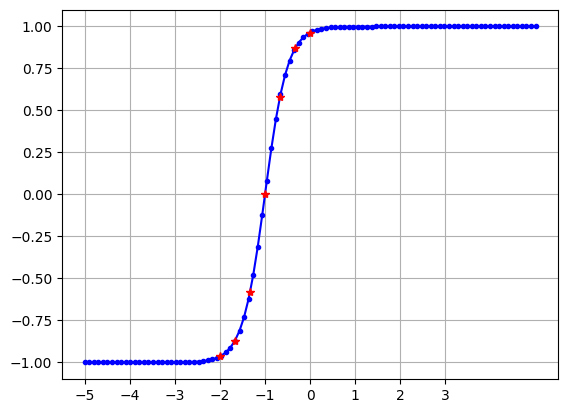

In [9]:
plt.figure(1)
xpoints = np.linspace(-5,5,100)
ypoints = [scurve_model(item, L, real_gravity/10) for item in xpoints]
plt.errorbar(xpoints, ypoints, marker = '.', color = 'blue')
plt.xticks([-5,-4,-3,-2,-1,0,1,2,3])
ypoints = [scurve_model(item/10, L, real_gravity/10) for item in biasList]
xpoints = np.array(biasList)/10
plt.errorbar(xpoints, ypoints, linestyle = "" ,marker = "*", color = "red")
plt.grid()
plt.savefig(f"scurve_L_{L}.png")

# Open The Workspace with the PDFs

In [10]:
f = ROOT.TFile("analysis_output/workspace.root")
w = f.Get("w")
w.Print("v")

w['c_pbarDn_1'].setVal(1.0); w['c_pbarDn_1'].setConstant(True)
w['c_pbarUp_1'].setVal(1.0); w['c_pbarUp_1'].setConstant(True)


RooWorkspace(w) w contents

variables
---------
(Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype)

p.d.f.s
-------
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooHistPdf::pdf_cosm[ pdfObs=(Z) ] = 1.8628
RooAddPdf::pdf_pbarDn[ c_pbarDn_1 * hpdf_pbarDn_1 + [%] * hpdf_pbarDn_2 ] = 0.0121951/1
RooAddPdf::pdf_pbarUp[ c_pbarUp_1 * hpdf_pbarUp_1 + [%] * hpdf_pbarUp_2 ] = 0.844512/1

datasets
--------
RooDataHist::rdhbin_pbarUp1(Z)
RooDataHist::rdhbin_pbarUp2(Z)
RooDataHist::rdhbin_pbarDn1(Z)
RooDataHist::rdhbin_pbarDn2(Z)

embedded datasets (in pdfs and functions)
-----------------------------------------
RooDataHist::rhcosm(Z)



In [11]:
Z = w['Z']
zframe = Z.frame(Title = "Z Distributions, Templates")
w['pdf_pbarUp'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kRed))
w['pdf_pbarDn'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kBlue))
w['pdf_cosm'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kGreen))

c = ROOT.TCanvas("pdfs_templates", "pdfs_templates", 600, 600)
ROOT.gPad.SetLeftMargin(0.15)
zframe.GetYaxis().SetTitleOffset(1.4)
zframe.Draw()
c.Draw()

# Create the RooDataSet

In [12]:
BiasCategory = ROOT.RooCategory("secondCategory", "a second category", BIAS)
BiasCategory.Print("v")

#dataset = ROOT.RooDataSet("data","data", ROOT.RooArgSet(Z,BiasCategory))

--- RooAbsArg ---
  Value State: clean
  Shape State: clean
  Attributes: 
  Address: 0x59eb98d236b0
  Clients: 
  Servers: 
  Proxies: 
--- RooAbsCategory ---
  Value = -20 "-2.0g)
  Possible states:
    -0.3g	-3
    -0.7g	-6
    -1.0g	-10
    -1.3g	-13
    -1.7g	-16
    -2.0g	-20
    0.0g	0


In [13]:
simModelBase = ROOT.RooSimultaneous("model_base_simultaneous", "model for bias", BiasCategory)

# 2. Crea un mapping da categoria (es. "-1.0g") a PDF personalizzato

pdf_per_categoria = {} # senno muoiono

for category, weight in weights.items():
    print(f"Setting up PDF for category: {category}")
    
    # Calcolo degli eventi Up/Down
    Nup   = 0.5 * weight * (1 - ASYMMETRY_TRUE[category])
    Ndown = 0.5 * weight * (1 + ASYMMETRY_TRUE[category])
    
    # Costanti per RooAddPdf
    nup_const = ROOT.RooFit.RooConst(Nup)
    ndwn_const = ROOT.RooFit.RooConst(Ndown)
    
    # PDF composita per questa categoria
    model_i = ROOT.RooAddPdf(f"pdf_{category}", f"pdf_{category}",
                             ROOT.RooArgList(w['pdf_pbarUp'], w['pdf_pbarDn']),
                             ROOT.RooArgList(nup_const, ndwn_const))
    pdf_per_categoria[category] = model_i
    
    # Aggiungila alla simultanea
    simModelBase.addPdf(model_i, category)

Setting up PDF for category: -2.0g
Setting up PDF for category: -1.7g
Setting up PDF for category: -1.3g
Setting up PDF for category: -1.0g
Setting up PDF for category: -0.7g
Setting up PDF for category: -0.3g
Setting up PDF for category: 0.0g


In [14]:
# Generazione separata per ciascuna categoria
dataset = simModelBase.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
dataset.Print("v")

DataStore hmaster (hmaster)
  Contains 14 entries
  Observables: 
    1)               Z = -450  L(-875.35 - -219.35) B(2)  "Z"
    2)  secondCategory = 0.0g(idx = 0)
  "a second category"


In [15]:
ttable = dataset.table(BiasCategory)
ttable.Print("v")


  Table secondCategory : hmaster
  +-------+-----+
  | -2.0g | 138 |
  | -1.7g | 152 |
  | -1.3g | 163 |
  | -1.0g | 165 |
  | -0.7g | 167 |
  | -0.3g | 159 |
  |  0.0g | 168 |
  +-------+-----+



In [16]:
c1 = ROOT.TCanvas("data_plot", "data_plot", 800, 800)

zframe1 = Z.frame( ROOT.RooFit.Bins(18), Title = "Plot of Z data")
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -30'), ROOT.RooFit.MarkerColor(ROOT.kBlue),  ROOT.RooFit.Name("cat_-30"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -20'), ROOT.RooFit.MarkerColor(ROOT.kRed),   ROOT.RooFit.Name("cat_-20"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == 30'), ROOT.RooFit.MarkerColor(ROOT.kGreen),  ROOT.RooFit.Name("cat_+30"))
#dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == +20'), ROOT.RooFit.MarkerColor(6),   ROOT.RooFit.Name("cat_-20"))
#w['model_base'].plotOn(zframe1)

#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kBlue))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-2.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kRed))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "+3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kGreen))

zframe1.Draw()

# Crea la legenda
legend = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)  # x1,y1,x2,y2 in NDC (posizione)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(zframe1.findObject("cat_-30"), "-3.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_-20"), "-2.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_+30"), "+3.0g", "lep")
legend.Draw()

c1.Draw()

[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1112 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 138 events out of 1112 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1112 total events


# Construction of the model for the Simulation

In [17]:
w.Import(BiasCategory) # <== Import the category inside the workspace

w.factory("S[100,50, 10000]")
w.factory("E[0.0, -1.5, 1.5]")
w.factory(f"D[{Dmu}, -0.8, 0.8]")

w.factory("SUM::model_base( Nup[30,10000] * pdf_pbarUp, Ndwn[30,1000] * pdf_pbarDn, nB[1, 200] * pdf_cosm)") # <<< Add pdf_cosm in the future
# A = (Ndwn - Nup)/(Ndwn + Nup)
w.factory(f"EDIT::model_MAGB(model_base, Nup=expr('0.5*S*(1-E)', S, E), Ndwn = expr('0.5*S*(1+E)', S, E))")

w.factory(f"Gaussian::Dconstr(D,{Dmu},{Dsigma})") # constrain on D, efficiency

w.factory("SIMCLONE::model_fit( model_MAGB, $SplitParam({S,E}, secondCategory ))") # Clone the Models

w.Print()

[#1] INFO:ObjectHandling -- RooWorkspace::import(w) importing RooCategory::secondCategory

RooWorkspace(w) w contents

variables
---------
(D,E,E_-0.3g,E_-0.7g,E_-1.0g,E_-1.3g,E_-1.7g,E_-2.0g,E_0.0g,Ndwn,Nup,S,S_-0.3g,S_-0.7g,S_-1.0g,S_-1.3g,S_-1.7g,S_-2.0g,S_0.0g,Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype,nB,secondCategory)

p.d.f.s
-------
RooGaussian::Dconstr[ x=D mean=0.02 sigma=0.08 ] = 1
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooAddPdf::model_MAGB[ model_MAGB_2 * pdf_pbarUp + model_MAGB_3 * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-0.3g[ model_MAGB_2_-0.3g * pdf_pbarUp + model_MAGB_3_-0.3g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-0.7g[ model_MAGB_2_-0.7g * pdf_pbarUp + model_MAGB_3_-0.7g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_

In [18]:
g = ROOT.TGraph("simulation.csv","%lg,%lg")
# create RooRealVar
w.factory('c[0,-30,30]')
#create RooRealVar
w.factory('scale[0.1]')
#w['scale'].setConstant(True)
w["nB"].setVal(nB_val)

# === Definisci la curva S come TF1 + RooTFnBinding ===
def Scurve_fn(x, p):
    # 10 is an offset of the simulation
    offset = -10
    bias = x[0]
    c = p[0]
    scale = p[1]
    D = p[2]
    return (g.Eval((x[0] - c + offset) * scale) - D)/(1 - g.Eval((x[0] - c + offset) * scale)*D)

# === Print values of the Scurve for a collection of biases ===
print("-"*8)
for key,value in BIAS.items():
    val = Scurve_fn([value], [w["c"].getVal(), w['scale'].getVal(), w['D'].getVal()])
    print(f"{key}| {value} | {w['c'].getVal()} | {val}")
print("-"*8)

# === create the RooFit model from the Scurve ===
Scurve_TF1 = ROOT.TF1("Scurve",Scurve_fn, -50, 50, 3) # not possible to put in workspace

cust = ROOT.RooCustomizer(w.pdf('model_fit'), "scurve");

vcat={}
nasy={}
for bkt, bias_val in BIAS.items():
    v = ROOT.RooRealVar(f"vat_{bkt}", "", bias_val)
    # Creo una funzione parametrica RooTFnBinding che connette il TF1 alla variabile 'v'
    # Il TF1 ha 3 parametri: c, scale, D — sono usati qui come [c, scale, D]
    asy = ROOT.RooTFnBinding(f"nasy_{bkt}", "", Scurve_TF1, v, [w['c'], w['scale'], w['D']])
    # Salvo queste entità nei dizionari
    vcat[bkt] = v
    nasy[bkt] = asy

    # Ottengo la variabile originale 'E_{bkt}' nel modello
    A = w.var(f'E_{bkt}')

    # Sostituisco E_{bkt} con la funzione curva S corrispondente
    cust.replaceArg(A, asy)

scurve_all = cust.build(True)

scurvemap = {}
for bkt, bias_val in BIAS.items():
    scurvemap.update({bkt : scurve_all.getPdf(bkt) })
    S = w.var(f'S_{bkt}')

    val = ttable.get(bkt)
    err = np.sqrt(val)
    
    #S.setMin(val-10*err)
    #S.setMax(val+10*err)
    S.setVal(val)
    print(f"setting  {val}  [{val - 10*err}  {val + 10*err}]")
    #S.setError(err)

scurve_fit = ROOT.RooSimultaneous("scurve_fit","scurve_fit", scurvemap, BiasCategory)

--------
-2.0g| -20 | 0.0 | -0.9993433969483587
-1.7g| -16 | 0.0 | -0.9967509653001462
-1.3g| -13 | 0.0 | -0.9892522450019776
-1.0g| -10 | 0.0 | -0.9647649394313713
-0.7g| -6 | 0.0 | -0.8371920868399894
-0.3g| -3 | 0.0 | -0.5473685472730021
0.0g| 0 | 0.0 | -0.020000000000000014
--------


setting  138.0  [20.526598755292696  255.4734012447073]
setting  152.0  [28.711719940620483  275.28828005937953]
setting  163.0  [35.32854665196297  290.67145334803706]
setting  165.0  [36.5476742133487  293.4523257866513]
setting  167.0  [37.77152016679915  296.2284798332008]
setting  159.0  [32.90479787081509  285.09520212918494]
setting  168.0  [38.38518603184281  297.6148139681572]


[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.3g will be replaced by nasy_-0.3g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.7g will be replaced by nasy_-0.7g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.0g will be replaced by nasy_-1.0g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.3g will be replaced by nasy_-1.3g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.7g will be replaced by nasy_-1.7g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-2.0g will be replaced by nasy_-2.0g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_0.0g will be replaced by nasy_0.0g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit) Branch node RooSimultaneous::model_fit cloned: depends on a replaced parameter
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit) Branch node RooAddPdf::model_MAGB

In [19]:
w['D'].setConstant(True)

w['c'].setError(20)
result = scurve_fit.fitTo(dataset,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.Minos(w['c']))

c     = w.var('c')
scale = w.var('scale')
D = w.var('D')

# === 8. Risultati
print("\n=== RISULTATI DEL FIT ===")
print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
print(f"fit status: {result.status()}")


=== RISULTATI DEL FIT ===
c     = -0.9944 ± 0.0248; [-0.02485125901268483,+0.024800411866650773]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using CPU computation library compiled with -mavx2
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 4500 convergence for edm < 1 strategy 2
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 4481.15966840840247
Edm   = 2.96980275407337682e-05
Nfcn  = 751
S_-0.3g	  = 158.138	 +/-  12.6109	(limited)
S_-0.7g	  = 166.053	 +/-  12.9263	(limited)
S_-1.0g	  = 163.991	

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       5154.360251 Edm =       73401.16424 NCalls =     37
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : 4985.05854
  Edm           : 340.5695663
  Internal parameters:	[     -1.361082125     -1.353493083     -1.355365661     -1.357254402     -1.367951771     -1.382430531     -1.352562725                0    -0.4441408246]	
  Internal gradient  :	[      455.7799139      610.0828939      541.3493529      322.6233119      220.0568655      174.6395209      292.7929634       1837.76538      0.759887708]	
  Internal covariance matrix:
[[  0.00046687689              0              0              0              0              0              0              0              0]
 [              0  0.00046070982   

In [20]:
scurve_fit.getParameters(dataset).Print('v')

  1) 0x59eb9904e890 RooRealVar::          D = 0.02 C  L(-0.8 - 0.8)  "D"
  2) 0x59eb994ada90 RooRealVar::    S_-0.3g = 158.138 +/- 12.6105  L(50 - 10000)  "S (-0.3g)"
  3) 0x59eb994faa40 RooRealVar::    S_-0.7g = 166.053 +/- 12.9259  L(50 - 10000)  "S (-0.7g)"
  4) 0x59eb99504600 RooRealVar::    S_-1.0g = 163.991 +/- 12.8447  L(50 - 10000)  "S (-1.0g)"
  5) 0x59eb9950e1c0 RooRealVar::    S_-1.3g = 162.058 +/- 12.7678  L(50 - 10000)  "S (-1.3g)"
  6) 0x59eb99461480 RooRealVar::    S_-1.7g = 151.051 +/- 12.3289  L(50 - 10000)  "S (-1.7g)"
  7) 0x59eb9946b040 RooRealVar::    S_-2.0g = 137.03 +/- 11.7443  L(50 - 10000)  "S (-2.0g)"
  8) 0x59eb99474bf0 RooRealVar::     S_0.0g = 167.014 +/- 12.958  L(50 - 10000)  "S (0.0g)"
  9) 0x59eb99423bb0 RooRealVar::          c = -9.94439 +/- (-0.248513,0.248004)  L(-30 - 30)  "c"
 10) 0x59eb957c3850 RooRealVar:: c_pbarDn_1 = 1 C  L(0.71251 - 1)  "c_pbarDn_1"
 11) 0x59eb918d4910 RooRealVar:: c_pbarUp_1 = 1 C  L(-0.0202152 - 1)  "c_pbarUp_1"
 12) 0x59eb

# SIMULATION, nominal case (2023 analysis), D set as constant

In [21]:
Ngravity = []
dNgravity = []

D.setConstant(True)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)

    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())
        
    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9958 ± 0.0244; [-0.024366802644776184,+0.024447079459086488]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0580 ± 0.0257; [-0.025884343177950814,+0.021818094166461716]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 se


=== RISULTATI DEL FIT ===
c     = -1.0443 ± 0.0271; [-0.024671430210732766,+0.027138785406871393]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0345 ± 0.0254; [-0.025635787076136108,+0.0253440333843469]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0



=== RISULTATI DEL FIT ===
c     = -0.9775 ± 0.0241; [-0.024064545855491296,+0.024064545855491296]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: -1
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9878 ± 0.0258; [-0.02561173161297757,+0.026074811011344443]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9822 ± 0.0251; [-0.025066555943711613,+0.025141333133738914]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -0.9893 ± 0.0242; [-0.02416266910808533,+0.024123160067032696]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0188 ± 0.0257; [-0.025391155364000384,+0.02589003281541921]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0395 ± 0.0260; [-0.0230169942184287,+0.02549667916969614]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 


=== RISULTATI DEL FIT ===
c     = -1.0198 ± 0.0285; [-0.028569340253534165,+0.02846203152048518]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9825 ± 0.0270; [-0.026981887405384448,+0.02703722290054202]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9762 ± 0.0271; [-0.026956729577391026,+0.026946547574741533]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set valu

...


=== RISULTATI DEL FIT ===
c     = -0.9885 ± 0.0252; [-0.024970046349129246,+0.02538329581470415]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9764 ± 0.0248; [-0.024691251318744653,+0.024706135611813035]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9613 ± 0.0256; [-0.025141668161405673,+0.02562991221384169]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set valu


=== RISULTATI DEL FIT ===
c     = -1.0047 ± 0.0245; [-0.024236302603052703,+0.024685322996191104]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0245 ± 0.0233; [-0.023317496431840237,+0.023323492883708344]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0078 ± 0.0263; [-0.026286164732126083,+0.026312546074489625]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -0.9714 ± 0.0268; [-0.026517063123332504,+0.025093368708043174]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0172 ± 0.0268; [-0.026807425333641277,+0.026870627526266767]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0107 ± 0.0262; [-0.026360662926933773,+0.026011730060749517]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -0.9882 ± 0.0273; [-0.027081636504905682,+0.0275728829752437]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9830 ± 0.0265; [-0.02634182615804811,+0.026629855768881584]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9931 ± 0.0255; [-0.025504738490914187,+0.025576743899224687]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating con

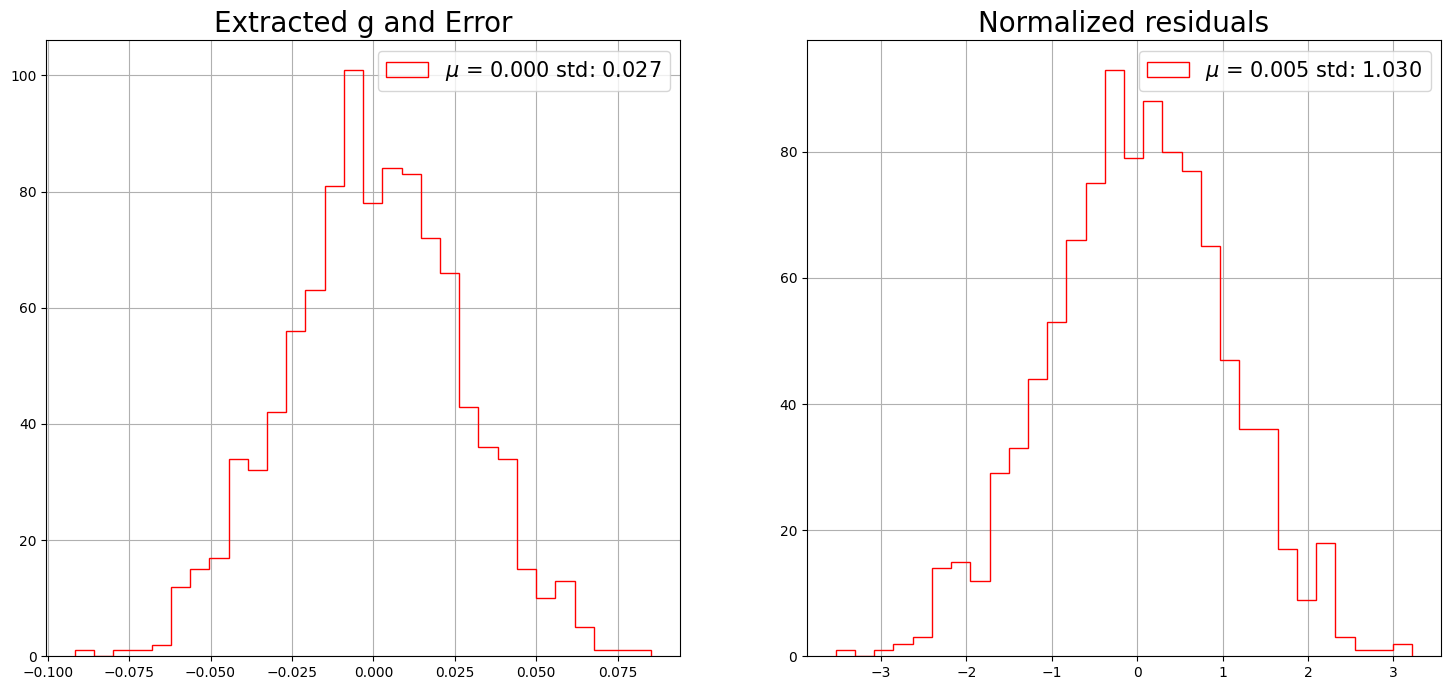

In [22]:
from matplotlib import pyplot as plt

#print(res_norm)
plt.figure(9, figsize = (18,8))
plt.subplot(1,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.subplot(1,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.savefig(f"residuals_L_{L}.png", bbox_inches = 'tight')

# Fit with D

In [23]:
Ngravity = []
dNgravity = []
ND = []
dND = []

D.setConstant(False)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)
    D.setVal(Dmu + np.random.normal(loc = 0, scale = Dsigma))  # D detector asymmetry, add a "manual smearing, because the simulation does not account for a generation of D"
    
    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())

    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 #ROOT.RooFit.Verbose(False),   # disattiva log verboso
                 #ROOT.RooFit.Warnings(False),  # opzionale: disattiva warning
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())
        ND.append(D.getVal() - Dmu)
        dND.append(D.getError())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)
Dres_norm = (np.array((ND)))/np.array(dND)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0294 ± 0.0515; [-0.044179436908505586,+0.05073742625423745]
scale = 0.1000 ± 0.0000
D     = 0.0251 ± 0.0843
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9754 ± 0.0479; [-0.04796955833834138,+0.04619113234018908]
scale = 0.1000 ± 0.0000
D     = 0.0194 ± 0.0790
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set v


=== RISULTATI DEL FIT ===
c     = -0.9668 ± 0.0479; [-0.04806588822987284,+0.0510208962038624]
scale = 0.1000 ± 0.0000
D     = 0.0220 ± 0.0791
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9689 ± 0.0427; [-0.042105096937415785,+0.05850888348176303]
scale = 0.1000 ± 0.0000
D     = 0.0320 ± 0.0736
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9942 ± 0.0470; [-0.04734158914089996,+0.045458730234649386]
scale = 0.1000 ± 0.0000
D     = 0.0191 ± 0.0793
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 


=== RISULTATI DEL FIT ===
c     = -0.9221 ± 0.0469; [-0.04924892279365503,+0.047549114702023935]
scale = 0.1000 ± 0.0000
D     = 0.0184 ± 0.0783
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9646 ± 0.0464; [-0.04540592468352015,+0.0544924263247671]
scale = 0.1000 ± 0.0000
D     = 0.0258 ± 0.0786
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0394 ± 0.0449; [-0.05208811740733548,+0.045467137603346676]
scale = 0.1000 ± 0.0000
D     = 0.0148 ± 0.0769
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 


=== RISULTATI DEL FIT ===
c     = -1.0041 ± 0.0440; [-0.04381638547086687,+0.04397375415698374]
scale = 0.1000 ± 0.0000
D     = 0.0187 ± 0.0749
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0290 ± 0.0501; [-0.045618987672626295,+0.04967262462312602]
scale = 0.1000 ± 0.0000
D     = 0.0228 ± 0.0817
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9919 ± 0.0457; [-0.04507233181967551,+0.04581812198387923]
scale = 0.1000 ± 0.0000
D     = 0.0216 ± 0.0781
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 


=== RISULTATI DEL FIT ===
c     = -1.0333 ± 0.0568; [-0.036734385167265064,+0.05688166095642801]
scale = 0.1000 ± 0.0000
D     = 0.0353 ± 0.0917
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0083 ± 0.0469; [-0.046659961675700856,+0.046766370094724924]
scale = 0.1000 ± 0.0000
D     = 0.0197 ± 0.0799
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0631 ± 0.0464; [-0.04658264192887702,+0.0486613473960242]
scale = 0.1000 ± 0.0000
D     = 0.0221 ± 0.0784
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value:

...


=== RISULTATI DEL FIT ===
c     = -1.0538 ± 0.0504; [-0.05192469597887561,+0.03859094702555619]
scale = 0.1000 ± 0.0000
D     = 0.0100 ± 0.0840
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9209 ± 0.0467; [-0.04878847009884976,+0.04634942747825871]
scale = 0.1000 ± 0.0000
D     = 0.0179 ± 0.0784
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9943 ± 0.0516; [-0.05123052498885277,+0.04896891506194569]
scale = 0.1000 ± 0.0000
D     = 0.0185 ± 0.0849
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 1


=== RISULTATI DEL FIT ===
c     = -0.9386 ± 0.0465; [-0.04699540637973049,+0.04614669216922806]
scale = 0.1000 ± 0.0000
D     = 0.0181 ± 0.0781
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9375 ± 0.0501; [-0.04416011745945801,+0.04989143546474509]
scale = 0.1000 ± 0.0000
D     = 0.0247 ± 0.0828
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0773 ± 0.0503; [-0.0505346012242757,+0.04542288207004144]
scale = 0.1000 ± 0.0000
D     = 0.0162 ± 0.0826
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 15


=== RISULTATI DEL FIT ===
c     = -1.0543 ± 0.0511; [-0.050500166881610624,+0.0425576938169725]
scale = 0.1000 ± 0.0000
D     = 0.0148 ± 0.0832
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9124 ± 0.0490; [-0.046861380054571446,+0.049457332535581655]
scale = 0.1000 ± 0.0000
D     = 0.0217 ± 0.0817
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0039 ± 0.0463; [-0.047147895630001525,+0.04563225234151369]
scale = 0.1000 ± 0.0000
D     = 0.0184 ± 0.0781
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value


=== RISULTATI DEL FIT ===
c     = -0.9951 ± 0.0493; [-0.0489395013442043,+0.04819977669722644]
scale = 0.1000 ± 0.0000
D     = 0.0194 ± 0.0816
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9698 ± 0.0521; [-0.05168600837046471,+0.044241594712741965]
scale = 0.1000 ± 0.0000
D     = 0.0149 ± 0.0838
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9076 ± 0.0451; [-0.04513158047535627,+0.044571818452475424]
scale = 0.1000 ± 0.0000
D     = 0.0182 ± 0.0761
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization --  Including the following constraint terms in minimization: (Dconstr)
[#1] INFO:Minimization -- The global observables are not defined , normalize constraints with respect to the parameters (D,S_-0.3g,S_-0.7g,S_-1.0g,S_-1.3g,S_-1.7g,S_-2.0g,S_0.0g,c,c_pbarDn_1,c_pbarUp_1,nB,scale,vat_-0.3g,vat_-0.7g,vat_-1.0g,vat_-1.3g,vat_-1.7g,vat_-2.0g,vat_0.0g)
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of events,

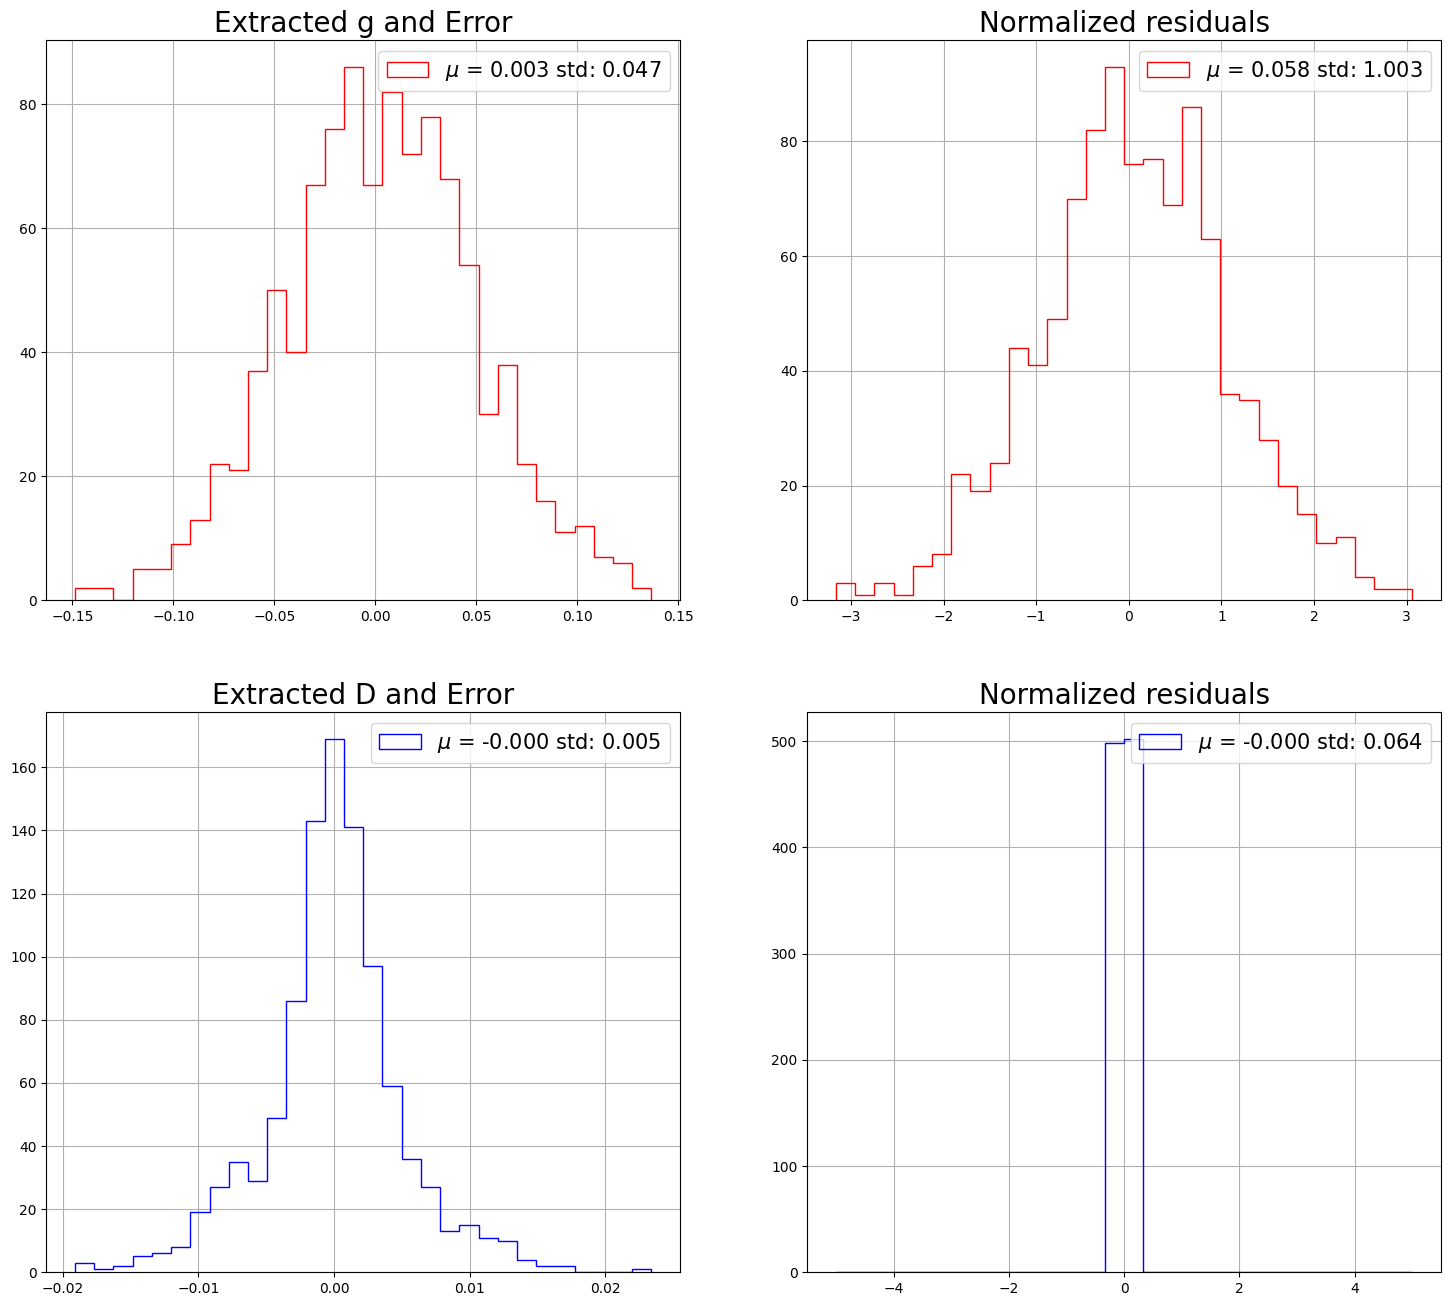

In [24]:
#print(res_norm)
plt.figure(10, figsize = (18,16))
plt.subplot(2,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

#plt.figure(11, figsize = (18,8))
plt.subplot(2,2,3)
plt.title("Extracted D and Error", fontsize = 20)
plt.grid()
plt.hist(ND, bins = 30, histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(ND):.3f} std: {np.std(ND):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,4)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(Dres_norm, bins = 30, range = (-5, 5), histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(Dres_norm):.3f} std: {np.std(Dres_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

plt.savefig(f"residuals_D_L_{L}.png", bbox_inches = 'tight')